In [88]:
import warnings
warnings.filterwarnings('ignore')

In [89]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.tree import DecisionTreeClassifier, plot_tree

my_palette = [
    '#6B72BA',
    '#F3A086',
    '#E77A65',
    '#2C4A60',
    '#B5B5B5'
]

sns.set_palette(my_palette)

sns.set_theme(
    style="white",
    palette=my_palette,
    font_scale=1.1,
    rc={
        'axes.spines.top': True,
        'axes.spines.right': True,
        'axes.spines.bottom': True,
        'axes.spines.left': True,
        'axes.edgecolor': 'black',
        'axes.linewidth': 1
    }
)

## ✅ Data Loading

In [90]:
df = pd.read_csv("/content/.config/hotel_bookings.csv")
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [91]:
df.shape

(119390, 32)

In [92]:
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


In [93]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

## ✅ Missing Values

In [94]:
count = df.isnull().sum()
percent = round((df.isnull().sum() / len(df)) *100, 2)

missing_df = pd.DataFrame({'Missing_count': count, 'Percentage(%)': percent})
missing_df = missing_df[missing_df['Missing_count'] > 0].sort_values(by='Missing_count')
display(missing_df)

,Missing_count,Percentage(%)
children,4,0.00
country,488,0.41
agent,16340,13.69
company,112593,94.31


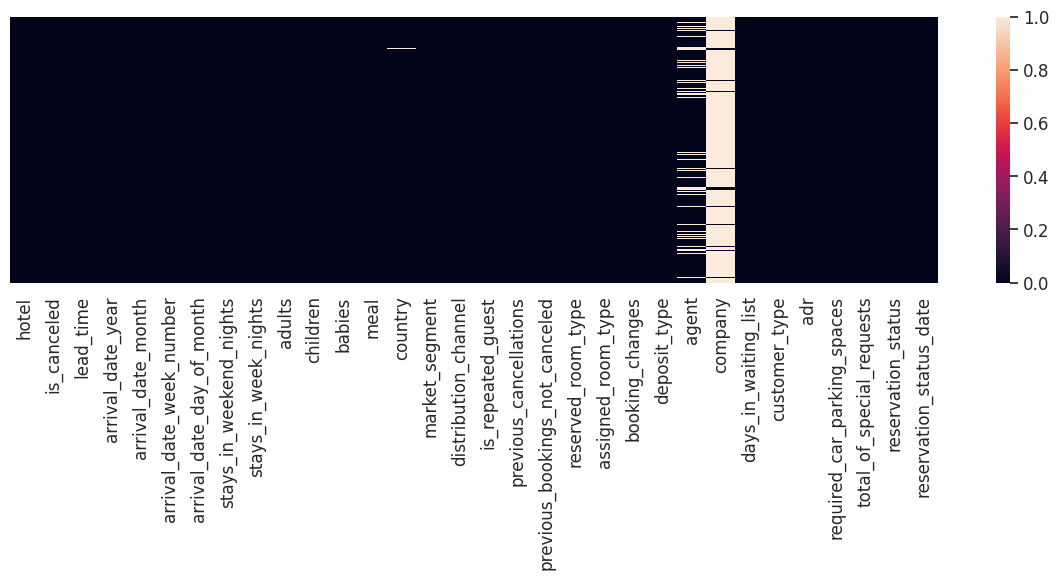

In [95]:
plt.figure(figsize=(12,6))
sns.heatmap(df.isna(),yticklabels=False)
plt.tight_layout()

In [96]:
df = df.drop(columns=['company'], errors='ignore')
df['agent'] = df['agent'].fillna(0)
df = df.dropna(subset=['children'])
df['country'] = df['country'].fillna('Unknown')

## ✅ Data Leakage

In [97]:
# remove the unnecessary columns
useless_col = ['days_in_waiting_list', 'assigned_room_type', 'booking_changes','country', 'reservation_status', 'reservation_status_date']

df.drop(useless_col, axis=1, inplace=True, errors='ignore')

In [98]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,deposit_type,agent,customer_type,adr,required_car_parking_spaces,total_of_special_requests
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,0,0,0,C,No Deposit,0.0,Transient,0.0,0,0
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,0,0,0,C,No Deposit,0.0,Transient,0.0,0,0
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,0,0,0,A,No Deposit,0.0,Transient,75.0,0,0
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,0,0,0,A,No Deposit,304.0,Transient,75.0,0,0
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,0,0,0,A,No Deposit,240.0,Transient,98.0,0,1


## ✅Feature Transformation

In [99]:
month_map = {
    'January': 1,
    'February': 2,
    'March': 3,
    'April': 4,
    'May': 5,
    'June': 6,
    'July': 7,
    'August': 8,
    'September': 9,
    'October': 10,
    'November': 11,
    'December': 12
}
df['arrival_date_month'] = df['arrival_date_month'].map(month_map)
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,deposit_type,agent,customer_type,adr,required_car_parking_spaces,total_of_special_requests
0,Resort Hotel,0,342,2015,7,27,1,0,0,2,...,0,0,0,C,No Deposit,0.0,Transient,0.0,0,0
1,Resort Hotel,0,737,2015,7,27,1,0,0,2,...,0,0,0,C,No Deposit,0.0,Transient,0.0,0,0
2,Resort Hotel,0,7,2015,7,27,1,0,1,1,...,0,0,0,A,No Deposit,0.0,Transient,75.0,0,0
3,Resort Hotel,0,13,2015,7,27,1,0,1,1,...,0,0,0,A,No Deposit,304.0,Transient,75.0,0,0
4,Resort Hotel,0,14,2015,7,27,1,0,2,2,...,0,0,0,A,No Deposit,240.0,Transient,98.0,0,1


In [100]:
# if there is any agent then show '1', if no agent then show '0'
df['has_agent'] = df['agent'].apply(lambda x:0 if x == 0 else 1)
df.drop(columns=['agent'], inplace=True)

In [101]:
num_cols = list(df.select_dtypes(include=['int64', 'float64']).columns)
cat_cols = list(df.select_dtypes(include=['object']).columns)

In [102]:
num_cols

['is_canceled',
 'lead_time',
 'arrival_date_year',
 'arrival_date_month',
 'arrival_date_week_number',
 'arrival_date_day_of_month',
 'stays_in_weekend_nights',
 'stays_in_week_nights',
 'adults',
 'children',
 'babies',
 'is_repeated_guest',
 'previous_cancellations',
 'previous_bookings_not_canceled',
 'adr',
 'required_car_parking_spaces',
 'total_of_special_requests',
 'has_agent']

In [103]:
cat_cols

['hotel',
 'meal',
 'market_segment',
 'distribution_channel',
 'reserved_room_type',
 'deposit_type',
 'customer_type']

## ✅ Outliers

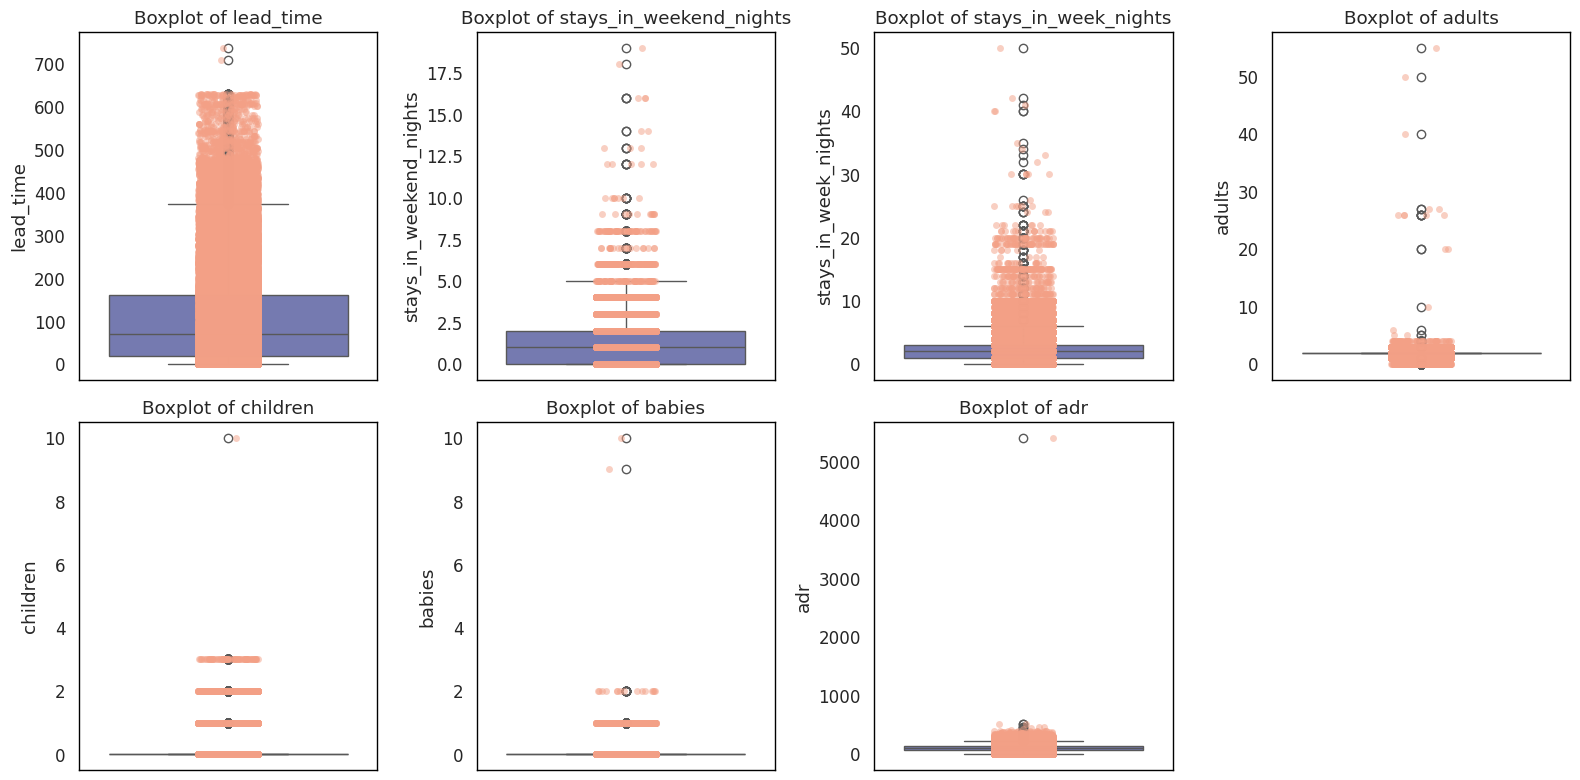

In [104]:
features = ['lead_time', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'adr']
n = 1
plt.figure(figsize=(16, 8))

for feature in features:
  plt.subplot(2, 4, n)
  sns.boxplot(y=df[feature])
  sns.stripplot(y=df[feature], alpha=0.5, jitter=True)
  plt.title(f"Boxplot of {feature}")
  n += 1

plt.tight_layout()
plt.show()

In [105]:
# remove the outlier for column 'adr' 'babies' 'children' 'adults'
df = df.loc[(df['adr'] >= 0) & (df['adr'] < 5000 )]
df = df.loc[df['babies'] <= 2]
df = df.loc[df['children'] <= 4]
df = df.loc[df['adults'] <= 5]

# make sure the sum of the three columns 'babies' 'children' 'adults' is more than 0
df = df[(df['adults'] + df['babies'] + df['children']) > 0]

# Winsorization
lead_time_99th = df['lead_time'].quantile(0.99)
df.loc[df['lead_time'] > lead_time_99th, 'lead_time'] = lead_time_99th

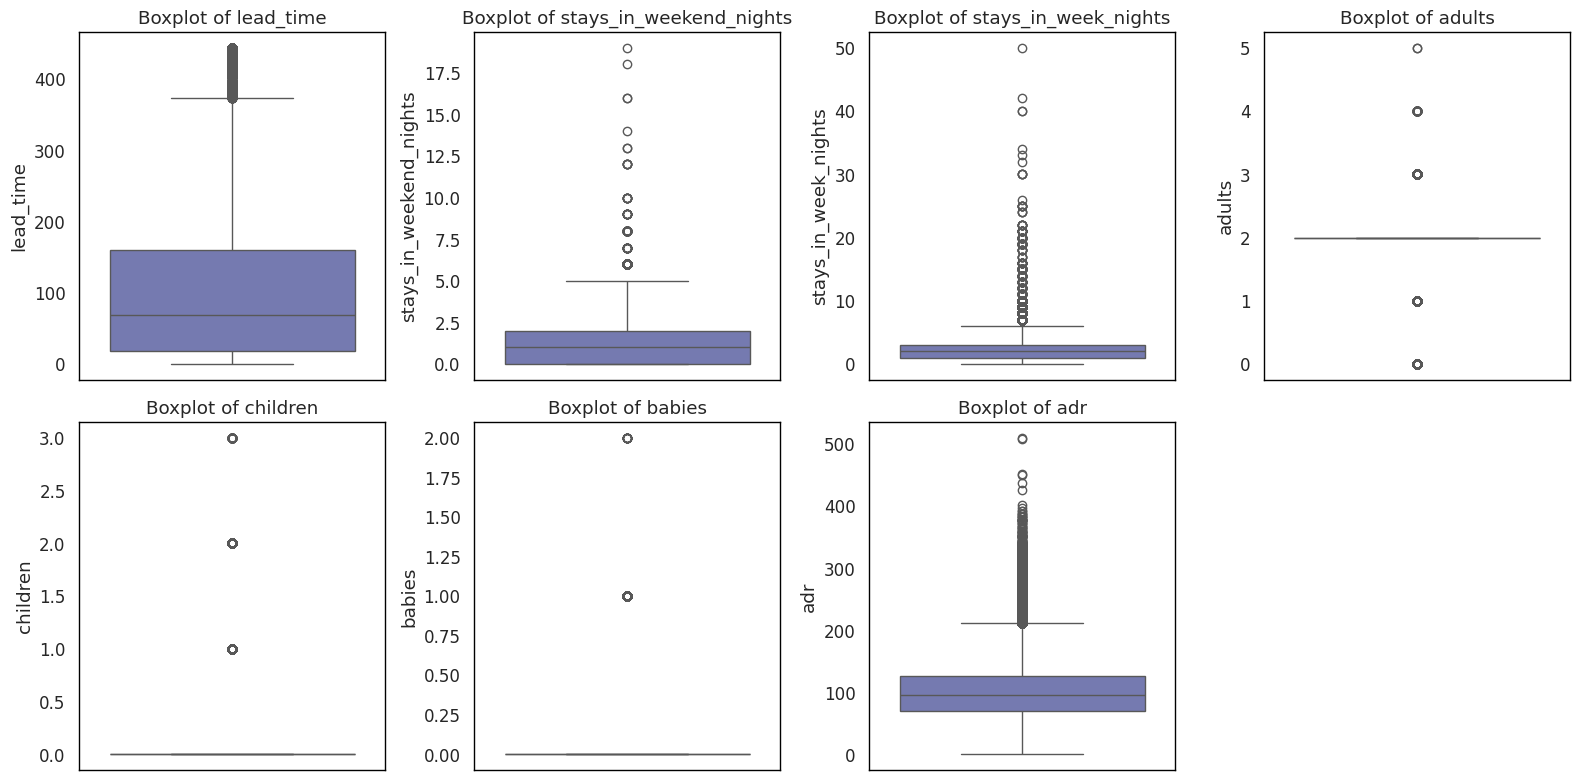

In [106]:
# check again if the outlier has been removed
features = ['lead_time', 'stays_in_weekend_nights', 'stays_in_week_nights','adults', 'children', 'babies',  'adr']
n = 1
plt.figure(figsize=(16, 8))

for feature in features:
  plt.subplot(2, 4, n)
  sns.boxplot(y=df[feature])
  plt.title(f"Boxplot of {feature}")
  n += 1

plt.tight_layout()
plt.show()

In [107]:
df[num_cols].describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,adr,required_car_parking_spaces,total_of_special_requests,has_agent
count,119187.000000,119187.000000,119187.000000,119187.000000,119187.000000,119187.000000,119187.000000,119187.000000,119187.000000,119187.000000,119187.000000,119187.000000,119187.000000,119187.000000,119187.000000,119187.000000,119187.000000,119187.00000
mean,0.370670,103.483408,2016.156661,6.551738,27.162123,15.799659,0.926930,2.498964,1.856184,0.103979,0.007803,0.031497,0.087207,0.137104,101.939899,0.062566,0.571556,0.86350
std,0.482986,104.586891,0.707390,3.089829,13.601348,8.781075,0.995057,1.896958,0.483998,0.397840,0.089408,0.174657,0.844999,1.498271,48.031663,0.245382,0.792907,0.34332
min,0.000000,0.000000,2015.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,0.000000,18.000000,2016.000000,4.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,69.525000,0.000000,0.000000,1.00000
50%,0.000000,69.000000,2016.000000,7.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,94.970000,0.000000,0.000000,1.00000
75%,1.000000,160.000000,2017.000000,9.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,126.000000,0.000000,1.000000,1.00000
max,1.000000,444.000000,2017.000000,12.000000,53.000000,31.000000,19.000000,50.000000,5.000000,3.000000,2.000000,1.000000,26.000000,72.000000,510.000000,8.000000,5.000000,1.00000


In [108]:
df[cat_cols].dtypes

,0
hotel,object
meal,object
market_segment,object
distribution_channel,object
reserved_room_type,object
deposit_type,object
customer_type,object


In [109]:
X = df.drop('is_canceled', axis= 1)
y = df['is_canceled']

In [110]:
X['hotel']

,hotel
0,Resort Hotel
1,Resort Hotel
2,Resort Hotel
3,Resort Hotel
4,Resort Hotel
...,...
119385,City Hotel
119386,City Hotel
119387,City Hotel
119388,City Hotel


## ✅One-Hot Encoding

In [111]:
X_encoded = pd.get_dummies(X, columns=cat_cols, drop_first=True)

print("columnas original ", df.shape[1])
print("columnas antes ", X.shape[1])
print("columnas Después ", X_encoded.shape[1])

columnas original  25
columnas antes  24
columnas Después  45


In [112]:
X_encoded.head()

,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,...,reserved_room_type_E,reserved_room_type_F,reserved_room_type_G,reserved_room_type_H,reserved_room_type_L,deposit_type_Non Refund,deposit_type_Refundable,customer_type_Group,customer_type_Transient,customer_type_Transient-Party
0,342,2015,7,27,1,0,0,2,0.0,0,...,False,False,False,False,False,False,False,False,True,False
1,444,2015,7,27,1,0,0,2,0.0,0,...,False,False,False,False,False,False,False,False,True,False
2,7,2015,7,27,1,0,1,1,0.0,0,...,False,False,False,False,False,False,False,False,True,False
3,13,2015,7,27,1,0,1,1,0.0,0,...,False,False,False,False,False,False,False,False,True,False
4,14,2015,7,27,1,0,2,2,0.0,0,...,False,False,False,False,False,False,False,False,True,False


In [113]:
X_encoded.columns

Index(['lead_time', 'arrival_date_year', 'arrival_date_month',
       'arrival_date_week_number', 'arrival_date_day_of_month',
       'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children',
       'babies', 'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'adr', 'required_car_parking_spaces',
       'total_of_special_requests', 'has_agent', 'hotel_Resort Hotel',
       'meal_FB', 'meal_HB', 'meal_SC', 'meal_Undefined',
       'market_segment_Complementary', 'market_segment_Corporate',
       'market_segment_Direct', 'market_segment_Groups',
       'market_segment_Offline TA/TO', 'market_segment_Online TA',
       'distribution_channel_Direct', 'distribution_channel_GDS',
       'distribution_channel_TA/TO', 'distribution_channel_Undefined',
       'reserved_room_type_B', 'reserved_room_type_C', 'reserved_room_type_D',
       'reserved_room_type_E', 'reserved_room_type_F', 'reserved_room_type_G',
       'reserved_room_type_H', 'res

In [114]:
X_encoded.isnull().sum().sum()

np.int64(0)

## ✅ Correlation Check

<Axes: >

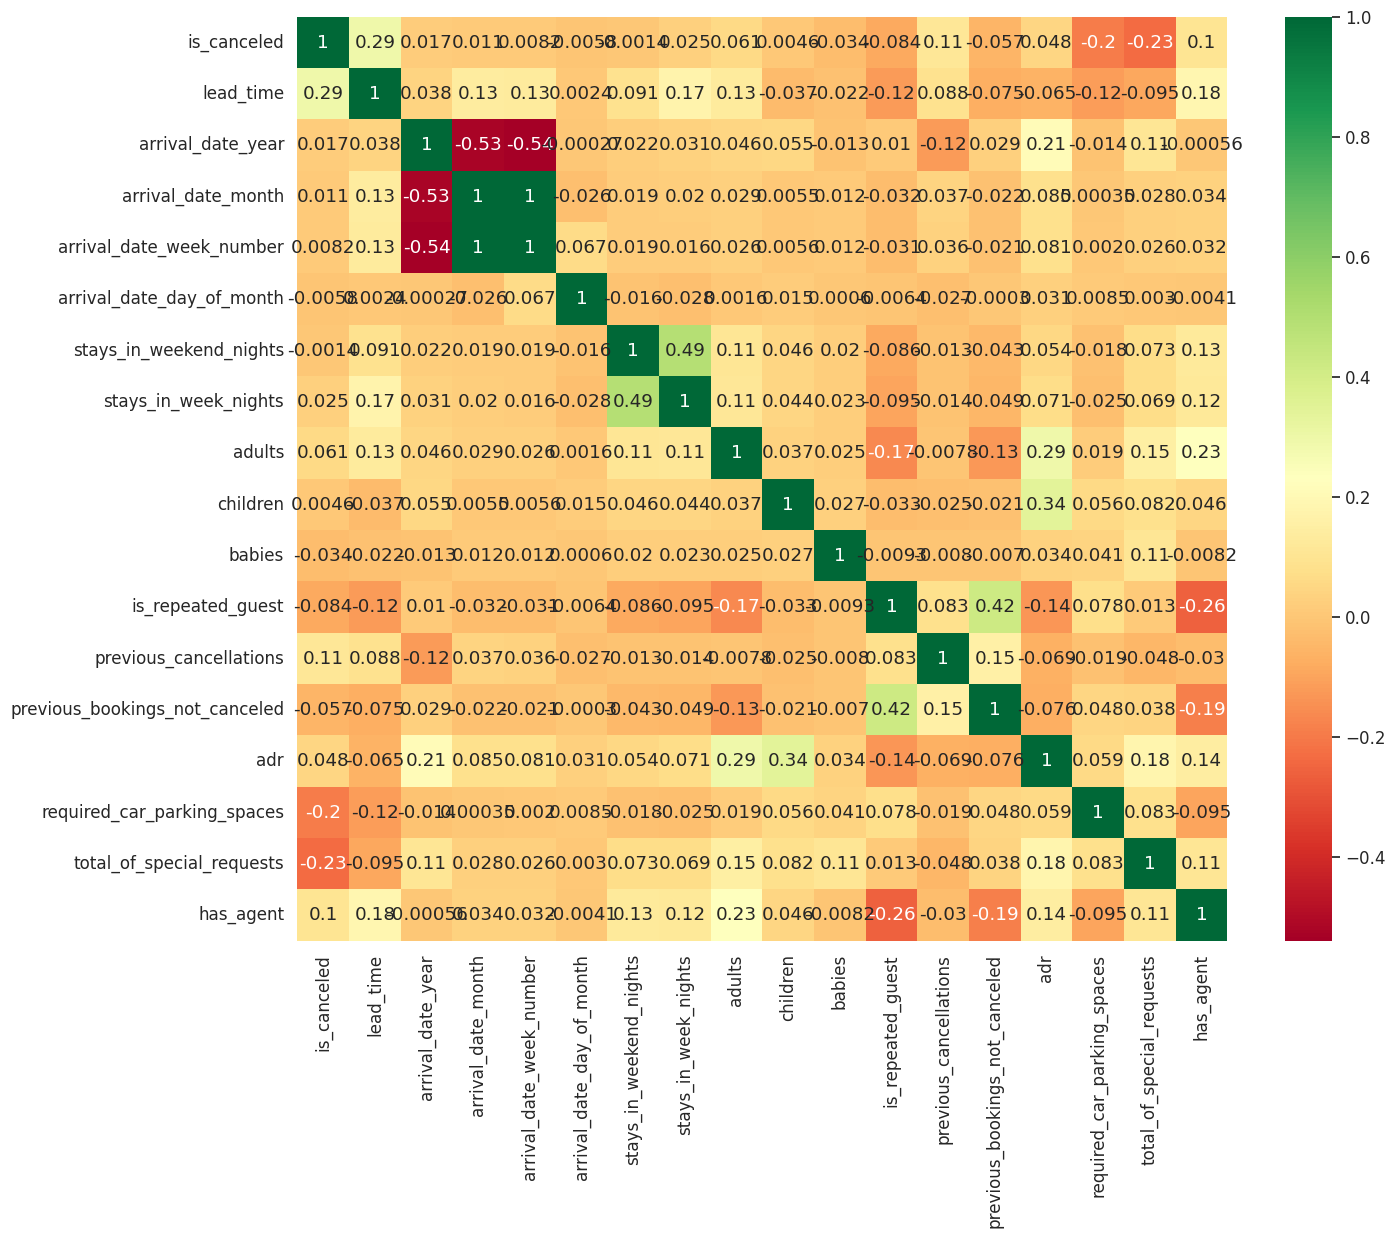

In [117]:
plt.figure(figsize=(15,12))
sns.heatmap(df.corr(numeric_only=True), annot=True,cmap='RdYlGn')

In [118]:
correlation = df.corr(numeric_only=True)['is_canceled'].abs().sort_values(ascending=False)
correlation

,is_canceled
is_canceled,1.000000
lead_time,0.293163
total_of_special_requests,0.234856
required_car_parking_spaces,0.195681
previous_cancellations,0.110176
has_agent,0.102535
is_repeated_guest,0.083696
adults,0.061004
previous_bookings_not_canceled,0.057347
adr,0.047989


## ✅ Feature Scaling

In [119]:
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42, stratify=y)

In [120]:
num_cols_to_scale = [
    'lead_time',
    'adr',
    'adults',
    'children',
    'babies',
    'stays_in_weekend_nights',
    'stays_in_week_nights'
]

In [121]:
scaler = StandardScaler()
X_train[num_cols_to_scale] = scaler.fit_transform(X_train[num_cols_to_scale])
X_test[num_cols_to_scale] = scaler.transform(X_test[num_cols_to_scale])

## ✅ Model Training: Logistic Regression

In [122]:
log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)

y_pred_lr = log_reg.predict(X_test)

accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)

print("Result trained with Logistic Regression: ")
print(f"Accuracy in test: {accuracy_lr:.2%}")
print(f"Precision in test: {precision_lr:.2%}")
print(f"Recall in test: {recall_lr:.2%}")
print(f"F1_score in test: {f1_lr:.2%}")

Result trained with Logistic Regression: 
Accuracy in test: 79.03%
Precision in test: 76.69%
Recall in test: 62.38%
F1_score in test: 68.80%


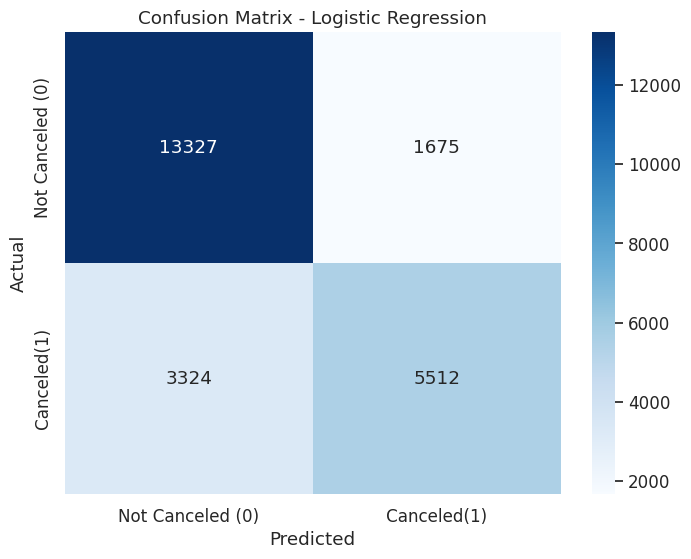

In [123]:
# calculate the Confusion Matriz
conf_matrix_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_lr,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=["Not Canceled (0)", "Canceled(1)"],
            yticklabels=["Not Canceled (0)", "Canceled(1)"]
)
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

## ✅ Decision Tree

In [124]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
tree_model = DecisionTreeClassifier(max_depth=3, random_state=42)
tree_model.fit(X_train, y_train)

y_pred_tree = tree_model.predict(X_test)

accuracy_tree = tree_model.score(X_test, y_test)

print("Result trained with Desicion Tree: ")
print(f"Accuracy in test: {accuracy_tree:.2%}")

Result trained with Desicion Tree: 
Accuracy in test: 76.54%


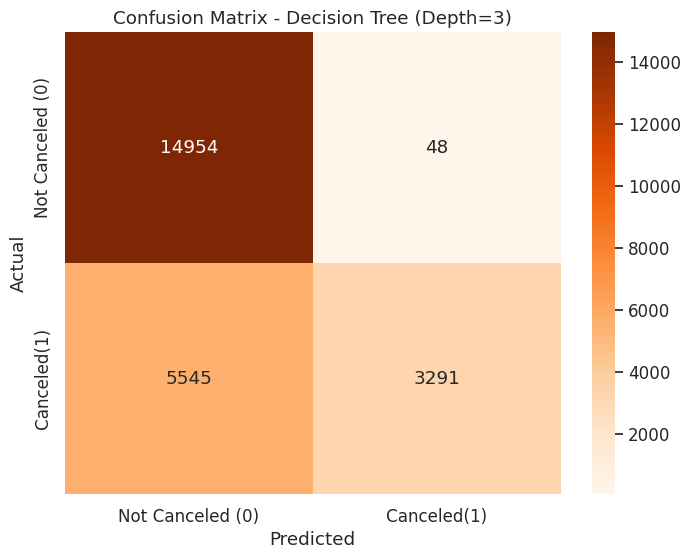

In [125]:
# calculate the Confusion Matriz
conf_matrix_tree = confusion_matrix(y_test, y_pred_tree)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_tree,
            annot=True,
            fmt="d",
            cmap="Oranges",
            xticklabels=["Not Canceled (0)", "Canceled(1)"],
            yticklabels=["Not Canceled (0)", "Canceled(1)"]
)
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.title("Confusion Matrix - Decision Tree (Depth=3)")
plt.show()

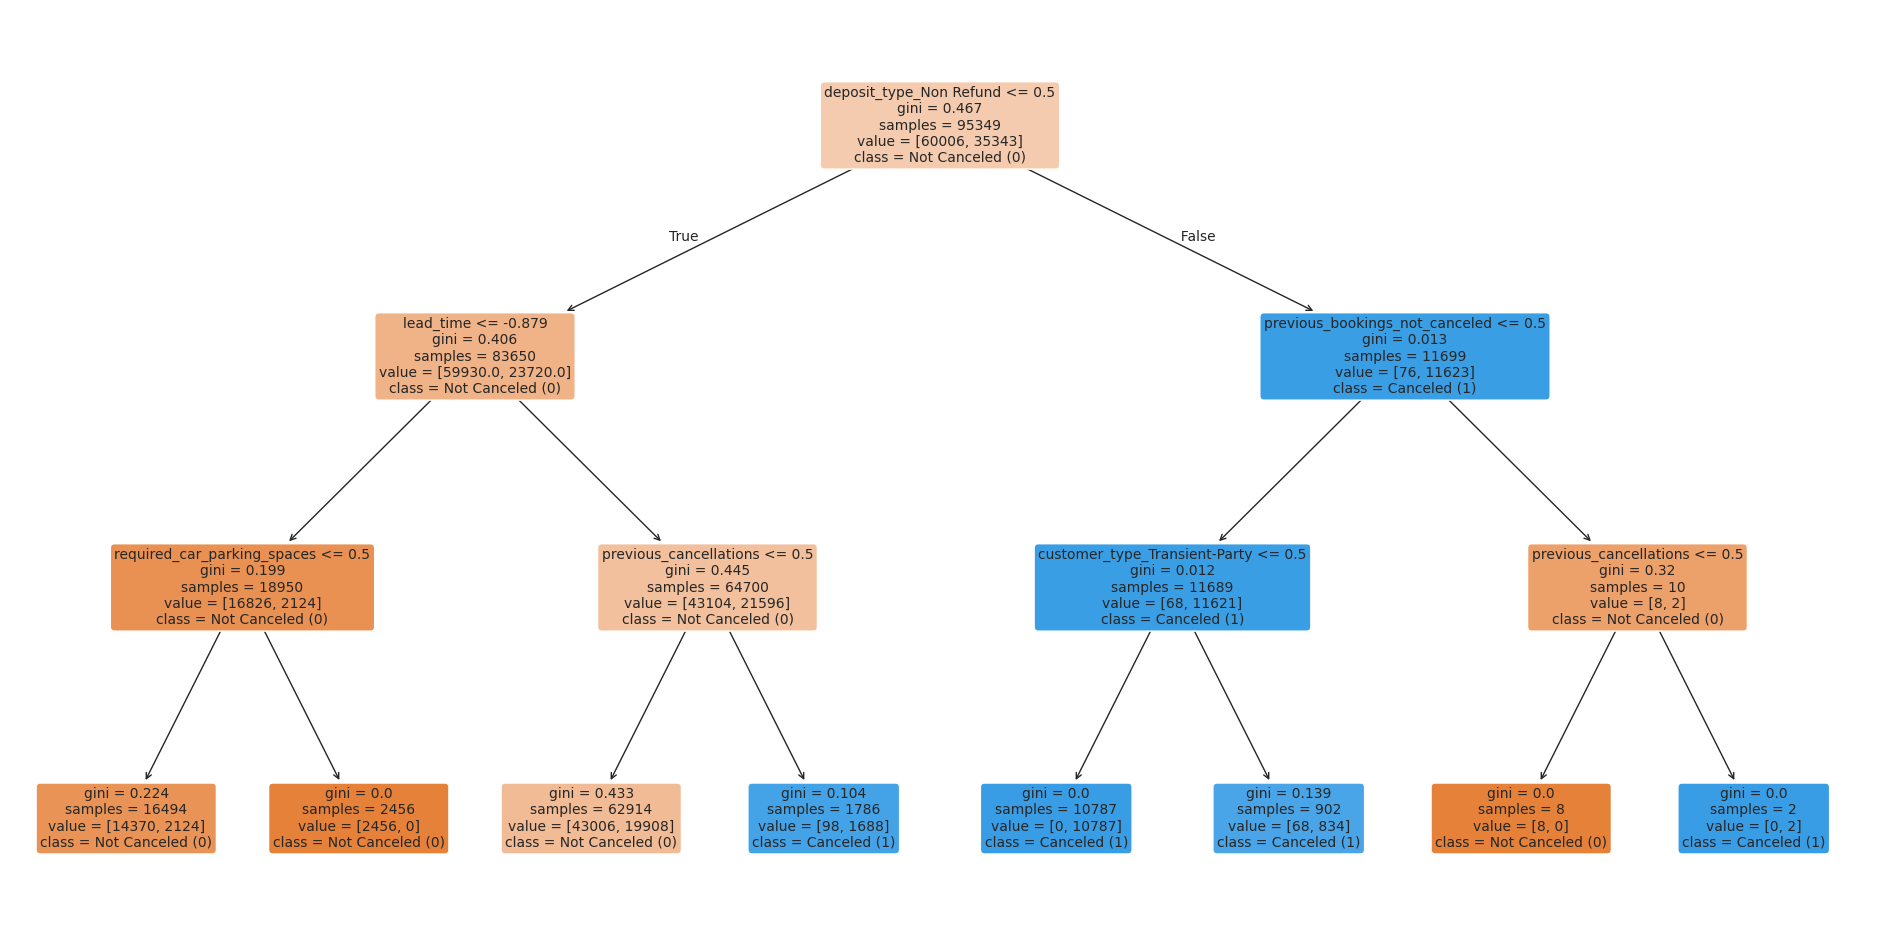

In [126]:
plt.figure(figsize=(24, 12))

plot_tree(
    tree_model,
    feature_names=X_train.columns,
    class_names=["Not Canceled (0)", "Canceled (1)"],
    filled=True,
    rounded=True,
    fontsize=10
)

plt.show()

### ✅ Grid Search with Cross Validation

In [127]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import time

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [15, 25, 35],
    'min_samples_split': [2, 10]
}

# total combinations
print(f"Total combinations {2*3*2} x 3 = {2*3*2*3} models")

start_time = time.time()

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=3
)

grid_search.fit(X_train, y_train)


end_time = time.time()
print(f"\nTraining Completed in: {(end_time - start_time) / 60:.2f} mins")

print(f"Best Parameteres: {grid_search.best_params_}")
print(f"Best score (CV): {grid_search.best_score_:.4f}")

# Predict the best model
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)


Total combinations 12 x 3 = 36 models
Fitting 3 folds for each of 12 candidates, totalling 36 fits

Training Completed in: 7.94 mins
Best Parameteres: {'max_depth': 35, 'min_samples_split': 2, 'n_estimators': 200}
Best score (CV): 0.8594


In [128]:
accuracy_gs = accuracy_score(y_test, y_pred)
precision_gs = precision_score(y_test, y_pred)
recall_gs = recall_score(y_test, y_pred)
f1_gs = f1_score(y_test, y_pred)

print("Model Evaluation")
print(f"Accuracy: {accuracy_gs:.2%}")
print(f"Precision: {precision_gs:.2%}")
print(f"Recall: {recall_gs:.2%}")
print(f"F1-Score: {f1_gs:.2%}")

Model Evaluation
Accuracy: 86.76%
Precision: 86.10%
Recall: 76.64%
F1-Score: 81.10%


## ✅ Random Forest

In [129]:
from sklearn.ensemble import RandomForestClassifier

# use the parameters obtained from GridSearch
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=35,
    min_samples_split=2,
    random_state=42,
    n_jobs=-1
  )

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print("Model Evaluation")
print(f"Accuracy: {accuracy_rf:.2%}")
print(f"Precision: {precision_rf:.2%}")
print(f"Recall: {recall_rf:.2%}")
print(f"F1-Score: {f1_rf:.2%}")

Model Evaluation
Accuracy: 86.76%
Precision: 86.10%
Recall: 76.64%
F1-Score: 81.10%


### Feature Importance

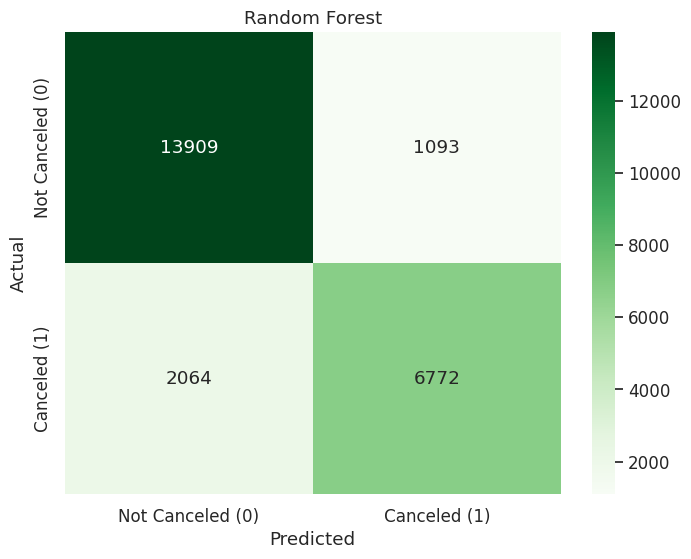

In [130]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(8,6))

sns.heatmap(cm_rf,
            annot=True,
            fmt='d',
            cmap='Greens',
            xticklabels=['Not Canceled (0)', 'Canceled (1)'],
            yticklabels=['Not Canceled (0)', 'Canceled (1)'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Random Forest')
plt.show()

In [131]:
feat_imp = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(feat_imp.head(10))

                      Feature  Importance
0                   lead_time    0.156970
40    deposit_type_Non Refund    0.134395
13                        adr    0.104607
4   arrival_date_day_of_month    0.073199
15  total_of_special_requests    0.066390
3    arrival_date_week_number    0.062542
6        stays_in_week_nights    0.046965
11     previous_cancellations    0.043713
2          arrival_date_month    0.036169
5     stays_in_weekend_nights    0.029124


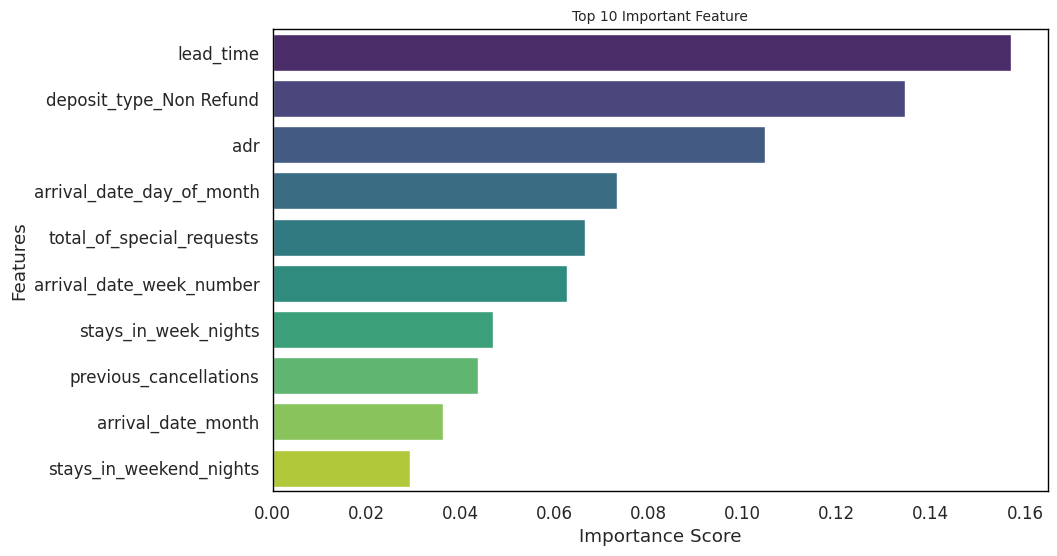

In [132]:
feat_imp = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=feat_imp.head(10),
    x='Importance',
    y='Feature',
    palette='viridis'
  )
plt.title('Top 10 Important Feature', fontsize=10)
plt.xlabel('Importance Score')
plt.ylabel('Features')

plt.show()